In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import numpy as np

from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [2]:
PATH = 'Crop_recommendation.csv'

# Load the CSV file data into
# data variable using pandas
data = pd.read_csv(PATH)

In [3]:
# Return the first five rows of CSV file
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
# Return information about the datatype,
# NULL type of the columns of CSV file
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
# describe
data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [6]:
# Return the number of unique labels 
data['label'].unique()

array(['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas',
       'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate',
       'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple',
       'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee'],
      dtype=object)

In [7]:
# Return the count of each unique label
data['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

C:\Users\quocd\AppData\Local\Temp\ipykernel_14416\4269449692.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[feat], color='greenyellow')
C:\Users\quocd\AppData\Local\Temp\ipykernel_14416\4269449692.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data[feat], color='greenyellow')
C:

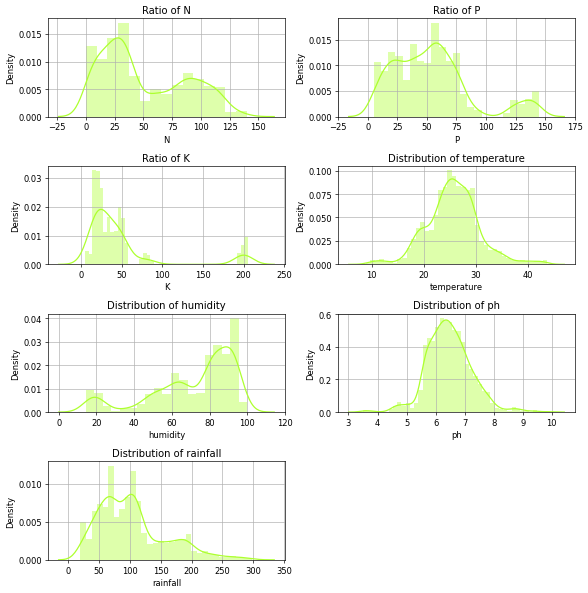

In [8]:
# over all distribution

plt.rcParams['figure.figsize'] = (10, 10)
plt.rcParams['figure.dpi'] = 60

features = ['N', 'P', 'K', 'temperature',
            'humidity', 'ph', 'rainfall']

for i, feat in enumerate(features):
    plt.subplot(4, 2, i + 1)
    sns.distplot(data[feat], color='greenyellow')
    if i < 3:
        plt.title(f'Ratio of {feat}', fontsize=12)
    else:
        plt.title(f'Distribution of {feat}', fontsize=12)
    plt.tight_layout()
    plt.grid()

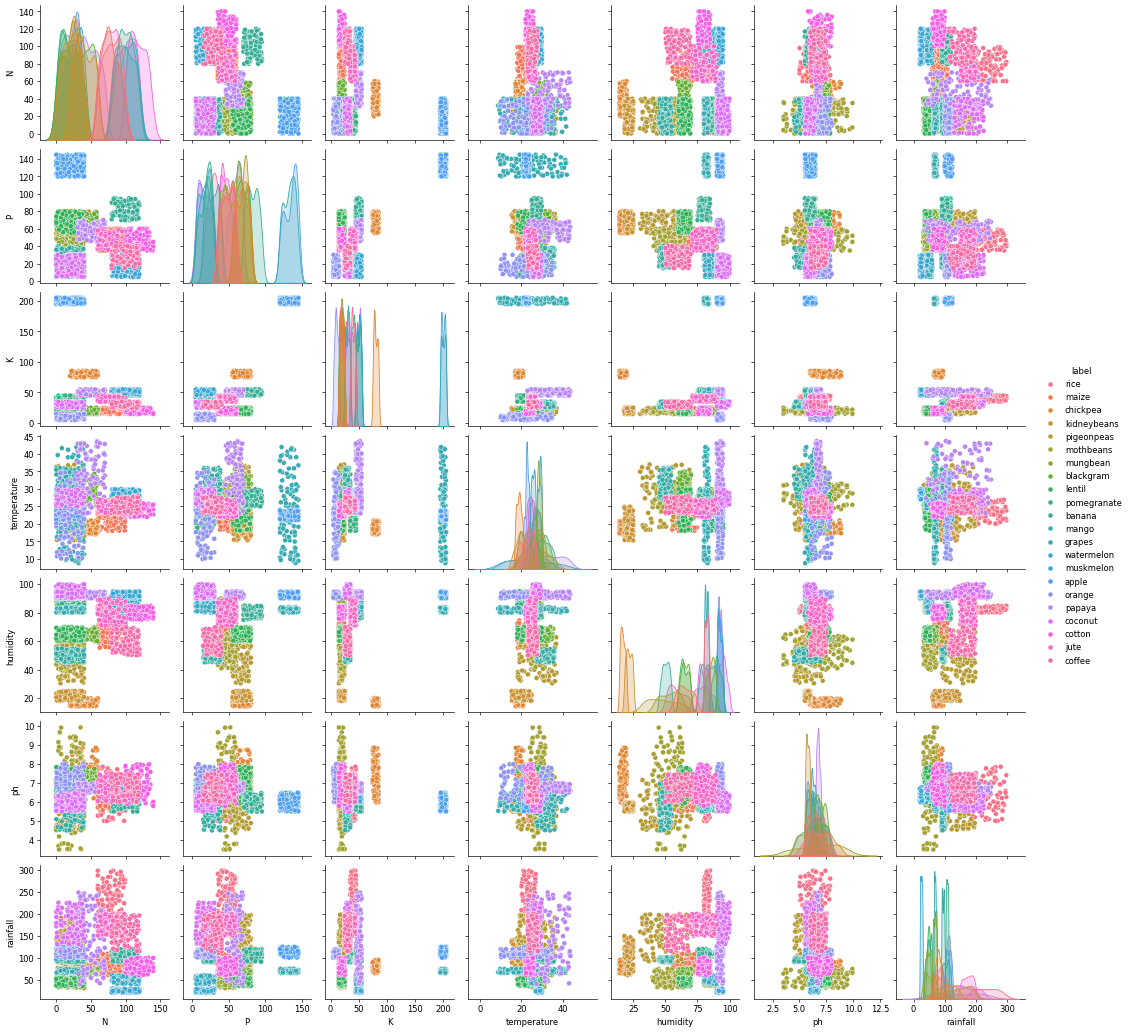

In [9]:
sns.pairplot(data, hue='label')

In [11]:
# Put all the input variables into features vector
features = data[['N', 'P', 'K', 'temperature',
                 'humidity', 'ph', 'rainfall']]

# Put all the output into labels array
labels = data['label']

In [12]:
X_train, X_test,\
    Y_train, Y_test = train_test_split(features,
                                       labels,
                                       test_size=0.2,
                                       random_state=42)

In [13]:
%%capture
# Pass the training set into the
# LogisticRegression model from Sklearn
LogReg = LogisticRegression(random_state=42)\
.fit(X_train, Y_train)

# Predict the values for the test dataset
predicted_values = LogReg.predict(X_test)

# Measure the accuracy of the test 
# set using accuracy_score metric
accuracy = metrics.accuracy_score(Y_test,
                                  predicted_values)

In [14]:
# Find the accuracy of the model
print("Logistic Regression accuracy: ", accuracy)

Logistic Regression accuracy:  0.9454545454545454


In [16]:
filename = 'LogisticRegresion.pkl'
MODELS = './recommender-models/'
# Use pickle to save ML model
pickle.dump(LogReg, open(MODELS + filename, 'wb'))